# 00 - Данные и санити-чек (Фаза 0)

Цель фазы: получить **чистый, выровненный набор лог-доходностей** и убедиться,
что в данных нет очевидных багов, прежде чем строить вейвлет-анализ.

Что показываем:
1. Загрузка цен (живые ccxt/yfinance, либо синтетический фолбэк).
2. Лог-доходности, выравнивание календаря (нюанс 24/7), чистка.
3. Санити-статистика: число наблюдений, пропуски, σ, асимметрия, эксцесс.
4. Графики: цены, доходности, скользящая волатильность.
5. Проверка ключевых явлений: всплеск корреляций в стрессе и депег стейблов.

> **Замечание про данные.** Если рыночные API недоступны (песочница/CI),
> пайплайн прозрачно переключается на синтетику с *встроенными* стресс-эпизодами.
> Синтетика - только для отладки пайплайна, не для реальных выводов. Заголовок
> ниже честно печатает, какой источник использован.

In [1]:
import sys, pathlib
# поднимаемся в корень репо, чтобы работал `import src`
ROOT = pathlib.Path.cwd()
if (ROOT / "src").exists() is False and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as C
from src import data_loader as dl
from src import preprocess as pp

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
FIG = C.FIGURES

## 1. Загрузка цен

Сначала пробуем живые источники; при сбое - синтетический фолбэк.

In [2]:
# use_synthetic=None -> авто: живые данные, при сбое синтетика.
# (Смотри логи WARNING выше - там честно печатается, если включился синтетический фолбэк.)
prices = dl.load_prices(use_synthetic=None)
print("Период:", prices.index.min().date(), "..", prices.index.max().date())
print("Форма:", prices.shape, "| колонки:", list(prices.columns))
prices.tail()

/sessions/amazing-great-hopper/mnt/QQ/src/data_loader.py:311: UserWarning: Live load failed (ModuleNotFoundError("No module named 'ccxt'")); falling back to synthetic data.
  warnings.warn(f"Live load failed ({e!r}); falling back to synthetic data.")
WARNING | data_loader | Live load failed: ModuleNotFoundError("No module named 'ccxt'") -> synthetic fallback


WARNING | data_loader | USING SYNTHETIC PRICES (no live data source reachable). Do NOT use for real conclusions - for pipeline/dev only.


Период: 2019-01-01 .. 2024-12-31
Форма: (2192, 11) | колонки: ['BTC', 'ETH', 'SOL', 'BNB', 'XRP', 'USDC', 'DAI', 'SP500', 'NASDAQ', 'GOLD', 'DXY']


,BTC,ETH,SOL,BNB,XRP,USDC,DAI,SP500,NASDAQ,GOLD,DXY
2024-12-27,85049.577686,1068.459050,3.956768,141.200848,4.412773,1.059231,1.063692,1965.130145,6736.870233,377.036298,199.930248
2024-12-28,90860.431988,1150.483162,4.226312,145.733028,4.874448,1.059616,1.063284,1995.744048,6919.164394,376.321501,197.849463
2024-12-29,91069.653650,1175.591929,4.322906,151.922487,4.903336,1.060119,1.064191,2018.449049,6917.147273,376.471954,197.097705
2024-12-30,92397.458271,1209.328425,4.450723,154.130076,4.836935,1.060718,1.064279,2012.923859,6903.685541,375.918589,196.544786
2024-12-31,90803.833655,1189.707699,4.358883,155.941006,4.767407,1.060161,1.064483,1984.073346,6819.847933,373.127754,196.675217


## 2. Лог-доходности, выравнивание и чистка

`build_returns` делает: выравнивание календаря (`trading_days` - крипта приводится к торговым дням традиционных активов) → чистка цен → лог-доходности → винзоризация хвостов (кроме стейблов, чьи депеги - это сигнал).

In [3]:
returns = pp.build_returns(prices, mode="trading_days", winsorize=True)
returns.to_parquet(C.PROCESSED_RETURNS)
prices.to_parquet(C.PROCESSED_PRICES)
print("returns:", returns.shape, "->", C.PROCESSED_RETURNS.relative_to(C.ROOT))
returns.head()

INFO | preprocess | winsorization skipped for: ['DAI', 'USDC'] (de-peg tails preserved)


INFO | preprocess | returns built: 1565 rows x 11 cols (2019-01-02 .. 2024-12-31)


returns: (1565, 11) -> data/processed/returns.parquet


,BTC,ETH,SOL,BNB,XRP,USDC,DAI,SP500,NASDAQ,GOLD,DXY
2019-01-02,-0.023445,-0.047365,-0.025931,-0.018616,-0.016777,0.000346,-0.000012,-0.000450,-0.015872,0.013860,-0.007182
2019-01-03,0.017110,-0.001684,0.015781,-0.003990,0.035963,-0.000356,-0.000075,-0.001702,0.002369,-0.003514,-0.003293
2019-01-04,0.032024,0.034306,0.057883,0.047410,0.036589,0.000108,-0.000063,-0.018507,-0.002338,0.012025,0.008454
2019-01-07,-0.054953,-0.096540,-0.165677,-0.011852,-0.036324,0.000782,0.000085,-0.014430,0.018410,0.010144,0.013778
2019-01-08,0.012414,0.002782,-0.049287,-0.018242,0.024603,-0.000058,-0.000549,0.004140,-0.009747,0.003183,-0.000614


## 3. Санити-статистика

Тяжёлые хвосты (эксцесс > 0) и отрицательная асимметрия у крипты - ожидаемы. У стейблов почти нулевая σ при огромном эксцессе - это и есть «спокойствие, прерываемое депегом».

In [4]:
stats = pp.sanity_stats(returns)
stats.to_csv(C.RESULTS / "phase0_sanity.csv")
stats.round(4)

,n_obs,missing_%,mean,std,ann_vol,skew,excess_kurt,min,max
BTC,1565,0.0,0.0020,0.0359,0.6867,-0.7407,4.3911,-0.2028,0.1325
ETH,1565,0.0,0.0013,0.0403,0.7696,-0.6959,4.6940,-0.2284,0.1751
SOL,1565,0.0,0.0005,0.0546,1.0436,-0.3590,2.5675,-0.2559,0.2174
BNB,1565,0.0,0.0015,0.0344,0.6564,-0.4644,3.2329,-0.1796,0.1366
XRP,1565,0.0,0.0017,0.0395,0.7545,-0.4321,2.4519,-0.2001,0.1369
USDC,1565,0.0,0.0001,0.0017,0.0326,-3.4262,479.9342,-0.0450,0.0384
DAI,1565,0.0,0.0001,0.0017,0.0317,-2.5433,470.6424,-0.0431,0.0380
SP500,1565,0.0,-0.0001,0.0171,0.3262,-0.5415,3.1498,-0.0911,0.0572
NASDAQ,1565,0.0,0.0000,0.0219,0.4183,-0.4320,2.4773,-0.1092,0.0766
GOLD,1565,0.0,0.0007,0.0087,0.1654,0.0687,0.7769,-0.0296,0.0331


## 4. Графики

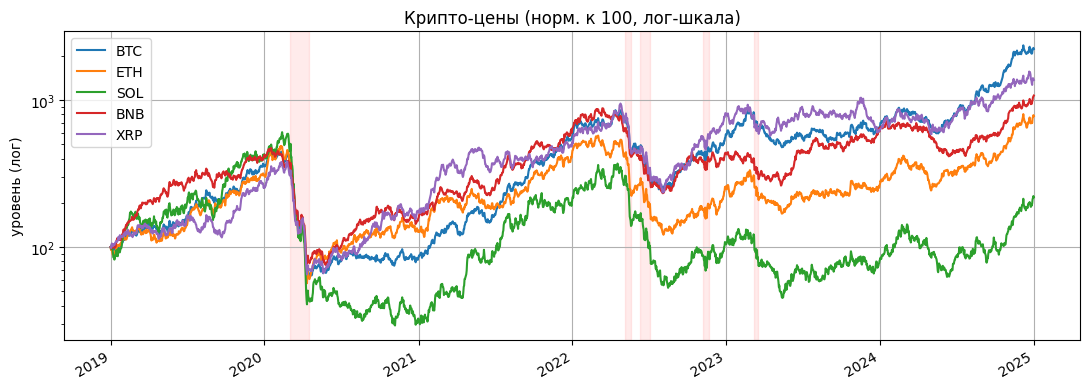

In [5]:
# 4.1 Нормированные цены (старт = 100), лог-шкала
norm = prices / prices.iloc[0] * 100
ax = norm[C.CRYPTO_CORE_COLS + ["SOL","BNB","XRP"]].plot(logy=True, title="Крипто-цены (норм. к 100, лог-шкала)")
for ep in C.EPISODES:
    ax.axvspan(pd.Timestamp(ep.start), pd.Timestamp(ep.end), color="red", alpha=0.08)
ax.set_ylabel("уровень (лог)"); plt.tight_layout(); plt.savefig(FIG/"00_crypto_prices.png", dpi=130); plt.show()

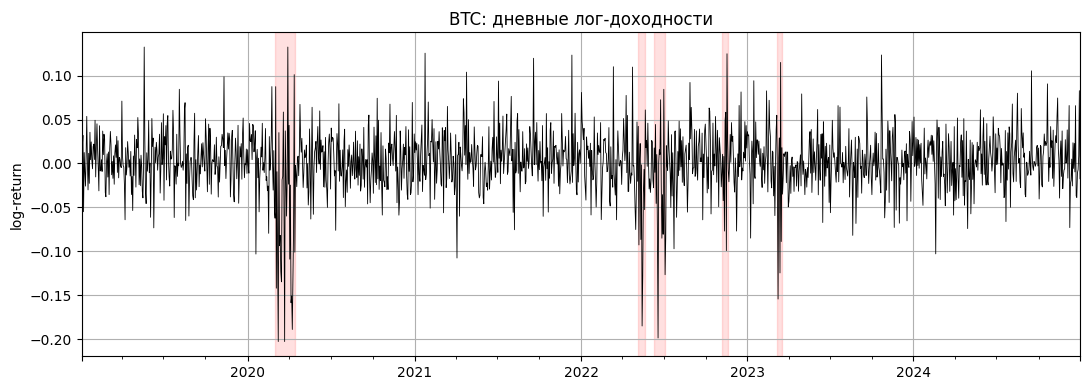

In [6]:
# 4.2 Доходности BTC с подсветкой эпизодов
ax = returns["BTC"].plot(title="BTC: дневные лог-доходности", color="black", lw=0.6)
for ep in C.EPISODES:
    ax.axvspan(pd.Timestamp(ep.start), pd.Timestamp(ep.end), color="red", alpha=0.12)
ax.set_ylabel("log-return"); plt.tight_layout(); plt.savefig(FIG/"00_btc_returns.png", dpi=130); plt.show()

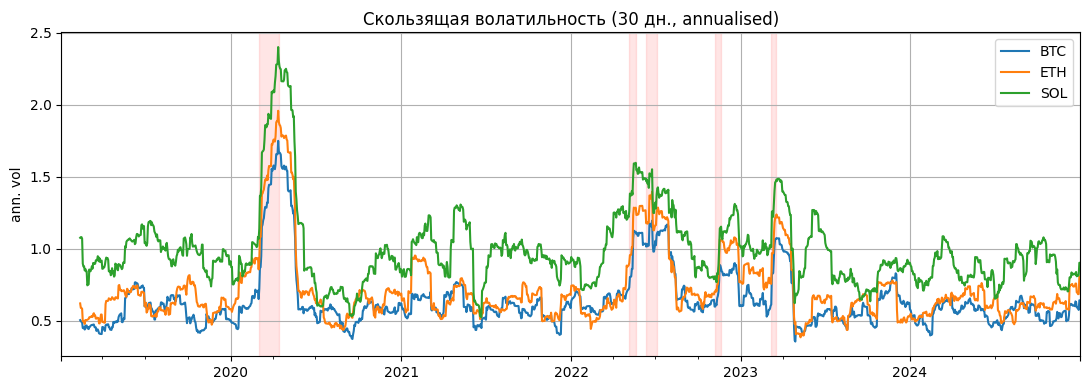

In [7]:
# 4.3 Скользящая 30-дн. волатильность (annualised)
roll = returns[["BTC","ETH","SOL"]].rolling(30).std() * np.sqrt(365)
ax = roll.plot(title="Скользящая волатильность (30 дн., annualised)")
for ep in C.EPISODES:
    ax.axvspan(pd.Timestamp(ep.start), pd.Timestamp(ep.end), color="red", alpha=0.10)
ax.set_ylabel("ann. vol"); plt.tight_layout(); plt.savefig(FIG/"00_rolling_vol.png", dpi=130); plt.show()

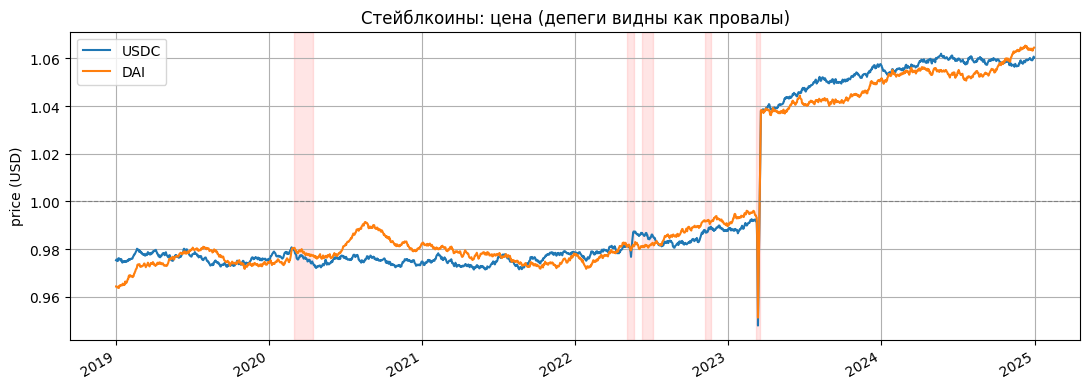

In [8]:
# 4.4 Стейблкоины: цена USDC/DAI и депеги
ax = prices[["USDC","DAI"]].plot(title="Стейблкоины: цена (депеги видны как провалы)")
ax.axhline(1.0, color="grey", ls="--", lw=0.8)
for ep in C.EPISODES:
    ax.axvspan(pd.Timestamp(ep.start), pd.Timestamp(ep.end), color="red", alpha=0.10)
ax.set_ylabel("price (USD)"); plt.tight_layout(); plt.savefig(FIG/"00_stablecoins.png", dpi=130); plt.show()

## 5. Проверка ключевых явлений

Прежде чем строить вейвлеты, грубо убеждаемся, что в данных есть то, ради чего проект затевался: **корреляции внутри крипты подскакивают в стрессе** и **стейблы депегаются** в Terra/USDC-окнах.

In [9]:
crypto = ["BTC","ETH","SOL","BNB","XRP"]
stress_idx = pd.Index([])
for ep in C.EPISODES:
    stress_idx = stress_idx.union(returns.index[(returns.index>=ep.start)&(returns.index<=ep.end)])
calm = returns.drop(index=stress_idx)

def mean_pair_corr(df):
    m = df[crypto].corr().values
    iu = np.triu_indices(len(crypto), 1)
    return m[iu].mean()

stress = returns.loc[stress_idx]
print("Средняя попарная корреляция крипты:")
print(f"  спокойно : {mean_pair_corr(calm):.3f}")
print(f"  стресс   : {mean_pair_corr(stress):.3f}")
print()
print(f"Худший день USDC: {returns['USDC'].min():.3%} ({returns['USDC'].idxmin().date()})")
print(f"Мин. цена USDC : {prices['USDC'].min():.4f}")

Средняя попарная корреляция крипты:
  спокойно : 0.633
  стресс   : 0.972

Худший день USDC: -4.504% (2023-03-13)
Мин. цена USDC : 0.9480


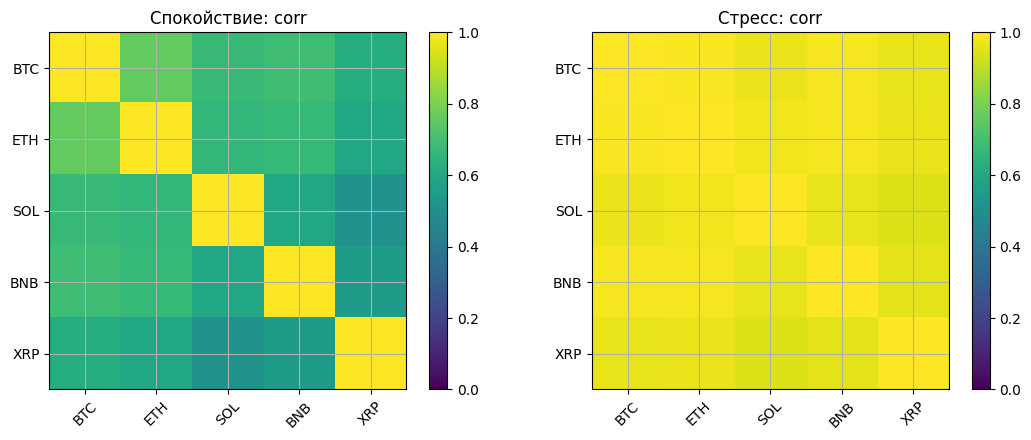

In [10]:
# Корреляционные матрицы: спокойствие vs стресс (наглядно)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (title, df) in zip(axes, [("Спокойствие", calm), ("Стресс", returns.loc[stress_idx])]):
    cm = df[crypto].corr()
    im = ax.imshow(cm, vmin=0, vmax=1, cmap="rocket" if "rocket" in plt.colormaps() else "viridis")
    ax.set_xticks(range(len(crypto))); ax.set_xticklabels(crypto, rotation=45)
    ax.set_yticks(range(len(crypto))); ax.set_yticklabels(crypto)
    ax.set_title(f"{title}: corr"); fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.savefig(FIG/"00_corr_calm_vs_stress.png", dpi=130); plt.show()

## Вывод по Фазе 0

- Получен выровненный, чистый набор лог-доходностей → `data/processed/returns.parquet`.
- Санити-статистика без очевидных багов; хвосты и асимметрия согласуются с природой активов.
- Депеги стейблов **сохранены** (винзоризация их не трогает) - это сигнал, а не выброс.
- Грубая проверка подтверждает контагион: попарная корреляция крипты резко растёт в стрессовых окнах.

Дальше - **Фаза 1 (бенчмарк)**: rolling-корреляция и (опц.) DCC-GARCH, чтобы показать,
что классика даёт одно усреднённое число и не видит горизонт.